# MSCS 634 - Lab 3
### **Lab 3**: Clustering Using K-Means and K-Medoids
### **Name** : Priya Thapa
### **Instructor** : Dr. Satish Penmatsa
### **Course**: MSCS 634 – Advanced Big Data and Data Mining


### **Step 1:** Load the Dataset

The Wine dataset is loaded from the Scikit-learn library and converted into a Pandas DataFrame for easier analysis. The original class labels are added as a separate column so they can later be compared with the clustering results.

In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Dataset
from sklearn.datasets import load_wine

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt

# Clustering
from sklearn.cluster import KMeans

# Evaluation metrics
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Load the Wine dataset
wine = load_wine()

# Create a DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Add the target labels
df["Class"] = wine.target

# Display the first five rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Explore the Dataset

In [6]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Class

In [7]:
# Display descriptive statistics
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


### Observation
Descriptive statistics summarize the distribution of each numerical feature, including the mean, standard deviation, minimum, maximum, and quartile values. This helps understand the scale and variability of the dataset before clustering.

### Examine Class Distribution

In [8]:
# Count samples in each class
print(df["Class"].value_counts())

Class
1    71
0    59
2    48
Name: count, dtype: int64


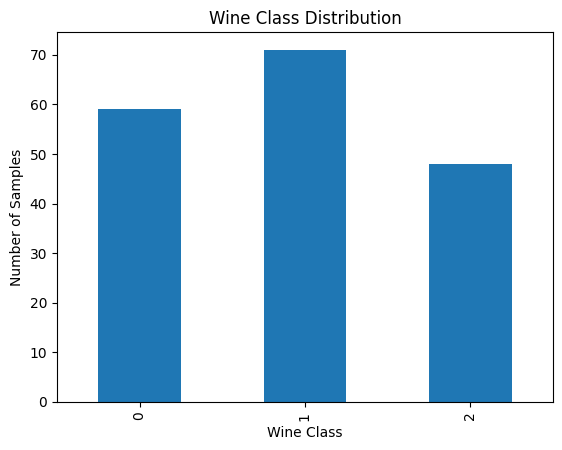

In [9]:
# Plot class distribution
df["Class"].value_counts().sort_index().plot(
    kind="bar",
    xlabel="Wine Class",
    ylabel="Number of Samples",
    title="Wine Class Distribution"
)

plt.show()

### Observation
Although clustering is an unsupervised learning technique, examining the original class distribution provides useful context for evaluating clustering performance later using the Adjusted Rand Index (ARI).

### Standardize the Dataset

In [10]:
# Separate features and labels
X = df.drop("Class", axis=1)
y = df["Class"]

# Standardize the features using z-score normalization
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Display first five standardized observations
pd.DataFrame(X_scaled, columns=X.columns).head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


### Observation
Since clustering algorithms rely on distance calculations, all features are standardized using z-score normalization. Standardization ensures that features measured on larger scales do not dominate those with smaller scales, allowing each feature to contribute equally during clustering.

### **Step 2** : Implement K-Means Clustering


### Train the K-Means Model

In [11]:
# Import K-Means clustering
from sklearn.cluster import KMeans

# Create the K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Train the model and obtain cluster labels
kmeans_labels = kmeans.fit_predict(X_scaled)

# Display the first 10 cluster assignments
print("First 10 Cluster Labels:")
print(kmeans_labels[:10])

First 10 Cluster Labels:
[2 2 2 2 2 2 2 2 2 2]


K-Means clustering partitions the dataset into a predefined number of clusters by minimizing the distance between each data point and its assigned cluster centroid. Since the Wine dataset contains three known classes, the algorithm is configured with k = 3. After training, each observation is assigned to one of the three clusters.

### Calculate the Silhouette Score

In [12]:
# Calculate the Silhouette Score
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:", round(kmeans_silhouette, 4))

K-Means Silhouette Score: 0.2849


The Silhouette Score measures how well each sample fits within its assigned cluster compared to neighboring clusters. The score ranges from -1 to 1, where values closer to 1 indicate well-separated and cohesive clusters. Higher scores generally indicate better clustering performance.

### Calculate the Adjusted Rand Index (ARI)

In [13]:
# Calculate the Adjusted Rand Index
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-Means Adjusted Rand Index (ARI):", round(kmeans_ari, 4))

K-Means Adjusted Rand Index (ARI): 0.8975


The Adjusted Rand Index (ARI) compares the cluster assignments generated by K-Means with the true class labels provided in the dataset. ARI values range from -1 to 1, where a value of 1 represents perfect agreement between the predicted clusters and the actual classes. Unlike accuracy, ARI accounts for agreement occurring by chance, making it a reliable metric for evaluating clustering performance.

### Display Both Metrics Together

In [14]:
# Display clustering performance metrics
print("K-Means Clustering Performance")
print("--------------------------------")
print(f"Silhouette Score : {kmeans_silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {kmeans_ari:.4f}")

K-Means Clustering Performance
--------------------------------
Silhouette Score : 0.2849
Adjusted Rand Index (ARI): 0.8975


The clustering performance is summarized using both evaluation metrics. The Silhouette Score evaluates the internal quality of the clusters based on cohesion and separation, while the Adjusted Rand Index (ARI) measures how closely the discovered clusters correspond to the actual wine classes. Together, these metrics provide a comprehensive assessment of the effectiveness of the K-Means clustering algorithm.

### **Step 3:** Implement K-Medoids Clustering
Unlike K-Means, K-Medoids is not included in the main sklearn.cluster module. We will use the KMedoids implementation from scikit-learn-extra. In K-Medoids, each cluster is represented by an actual observation from the dataset called a medoid

In [15]:
# Install the compatible K-Medoids package
!pip install kmedoids

# Import the K-Medoids package
import kmedoids

# Import the function used to calculate pairwise distances
from sklearn.metrics import pairwise_distances

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.8/458.8 kB 22.8 MB/s eta 0:00:00


In [16]:
# Calculate pairwise Euclidean distances between all observations
distance_matrix = pairwise_distances(
    X_scaled,
    metric="euclidean"
)

print("Distance Matrix Shape:", distance_matrix.shape)

Distance Matrix Shape: (178, 178)


### Train the K-Meoids model

In [17]:
# Apply K-Medoids clustering using the FasterPAM algorithm
kmedoids_result = kmedoids.fasterpam(
    distance_matrix,
    medoids=3,
    random_state=42
)

# Obtain the cluster labels
kmedoids_labels = kmedoids_result.labels

# Display the first 10 cluster assignments
print("First 10 K-Medoids Cluster Labels:")
print(kmedoids_labels[:10])

First 10 K-Medoids Cluster Labels:
[1 1 1 1 1 1 1 1 1 1]


### Calculate the Silhouette Score

In [18]:
# Calculate the Silhouette Score
kmedoids_silhouette = silhouette_score(
    X_scaled,
    kmedoids_labels
)

print("K-Medoids Silhouette Score:", round(kmedoids_silhouette, 4))

K-Medoids Silhouette Score: 0.2676


The Silhouette Score measures how well each observation fits within its assigned cluster compared to neighboring clusters. The score ranges from -1 to 1, where values closer to 1 indicate well-defined and clearly separated clusters.

### Calculate the Adjusted Rand Index (ARI)

In [19]:
# Calculate the Adjusted Rand Index
kmedoids_ari = adjusted_rand_score(
    y,
    kmedoids_labels
)

print("K-Medoids Adjusted Rand Index (ARI):", round(kmedoids_ari, 4))

K-Medoids Adjusted Rand Index (ARI): 0.7411


The Adjusted Rand Index (ARI) compares the clusters generated by the K-Medoids algorithm with the actual Wine dataset class labels. The metric ranges from -1 to 1, where a value closer to 1 indicates stronger agreement between the clustering results and the true class labels.

### Display Both Metrics Together

In [20]:
# Display the K-Medoids clustering performance
print("K-Medoids Clustering Performance")
print("--------------------------------")
print(f"Silhouette Score : {kmedoids_silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {kmedoids_ari:.4f}")

K-Medoids Clustering Performance
--------------------------------
Silhouette Score : 0.2676
Adjusted Rand Index (ARI): 0.7411


The clustering performance is summarized using both the Silhouette Score and the Adjusted Rand Index. The Silhouette Score evaluates the quality of the cluster structure, while the ARI measures how closely the generated clusters correspond to the actual wine classes. Together, these metrics provide a comprehensive assessment of the K-Medoids clustering algorithm.

### **Step 4:** Visualize and Compare Results


### Reduce the Dataset to Two Dimensions\

In [21]:
# Import Principal Component Analysis
from sklearn.decomposition import PCA

# Reduce the standardized dataset to two principal components
pca = PCA(n_components=2)

# Transform the standardized observations
X_pca = pca.fit_transform(X_scaled)

# Display the first five PCA-transformed observations
print("First Five PCA Observations:")
print(X_pca[:5])

First Five PCA Observations:
[[ 3.31675081  1.44346263]
 [ 2.20946492 -0.33339289]
 [ 2.51674015  1.0311513 ]
 [ 3.75706561  2.75637191]
 [ 1.00890849  0.86983082]]


Principal Component Analysis (PCA) is used to reduce the Wine dataset from thirteen features to two principal components. This dimensionality reduction preserves most of the variation in the data while allowing the clusters to be visualized on a two-dimensional scatter plot.

### Transform the K-Means Centroids

In [23]:
# Transform the K-Means centroids into PCA space
kmeans_centers_pca = pca.transform(
    kmeans.cluster_centers_
)

print("K-Means Centroids in PCA Space:")
print(kmeans_centers_pca)

K-Means Centroids in PCA Space:
[[-0.03695661 -1.77223945]
 [-2.72003575  1.12565126]
 [ 2.2761936   0.93205403]]


The K-Medoids medoids are projected into the PCA space to visualize the representative observations selected for each cluster.

### Obtain the K-Medoids Medoid Coordinates

In [24]:
# Obtain the indices of the selected medoids
kmedoids_medoid_indices = kmedoids_result.medoids

# Retrieve the standardized coordinates of the medoids
kmedoids_centers = X_scaled[kmedoids_medoid_indices]

print("K-Medoids Medoid Indices:")
print(kmedoids_medoid_indices)

print("\nK-Medoids Medoid Coordinates:")
print(kmedoids_centers)

K-Medoids Medoid Indices:
[106  35 148]

K-Medoids Medoid Coordinates:
[[-9.27212090e-01 -5.44296535e-01 -9.01103141e-01 -1.48624201e-01
  -1.38612179e+00 -1.03368389e+00  7.33234123e-04  6.56394314e-02
   6.85084581e-02 -7.17239912e-01  1.86683727e-01  7.88587455e-01
  -7.54385098e-01]
 [ 5.92163817e-01 -4.72483484e-01  1.58945723e-01  3.01803287e-01
   1.81450206e-02  6.48764240e-01  9.54501620e-01 -8.20719236e-01
   4.71487808e-01  1.81290590e-02  3.62177276e-01  1.21232030e+00
   5.51257335e-01]
 [ 3.94521423e-01  8.11174814e-01  4.92854954e-02  6.02088279e-01
  -5.43561704e-01 -5.85031052e-01 -1.27430450e+00  7.10263917e-01
  -5.97283511e-01  1.45426140e+00 -1.78761869e+00 -1.40069891e+00
  -3.08555975e-01]]


K-Medoids uses actual observations as cluster representatives. The medoids attribute identifies the row indices of the observations selected as medoids. These observations are retrieved from the standardized dataset before being transformed into PCA space.

### Transform the K-Medoids Medoids

In [25]:
# Transform the medoids into PCA space
kmedoids_centers_pca = pca.transform(
    kmedoids_centers
)

print("K-Medoids Medoids in PCA Space:")
print(kmedoids_centers_pca)

K-Medoids Medoids in PCA Space:
[[-0.36626736 -2.1693533 ]
 [ 1.90382623  0.17671095]
 [-2.80706372  1.57053379]]


The selected medoid observations are transformed into the same two-dimensional PCA space as the rest of the dataset. This allows the medoids to be marked clearly on the K-Medoids clustering plot.

### Create Side-by-Side Scatter Plots

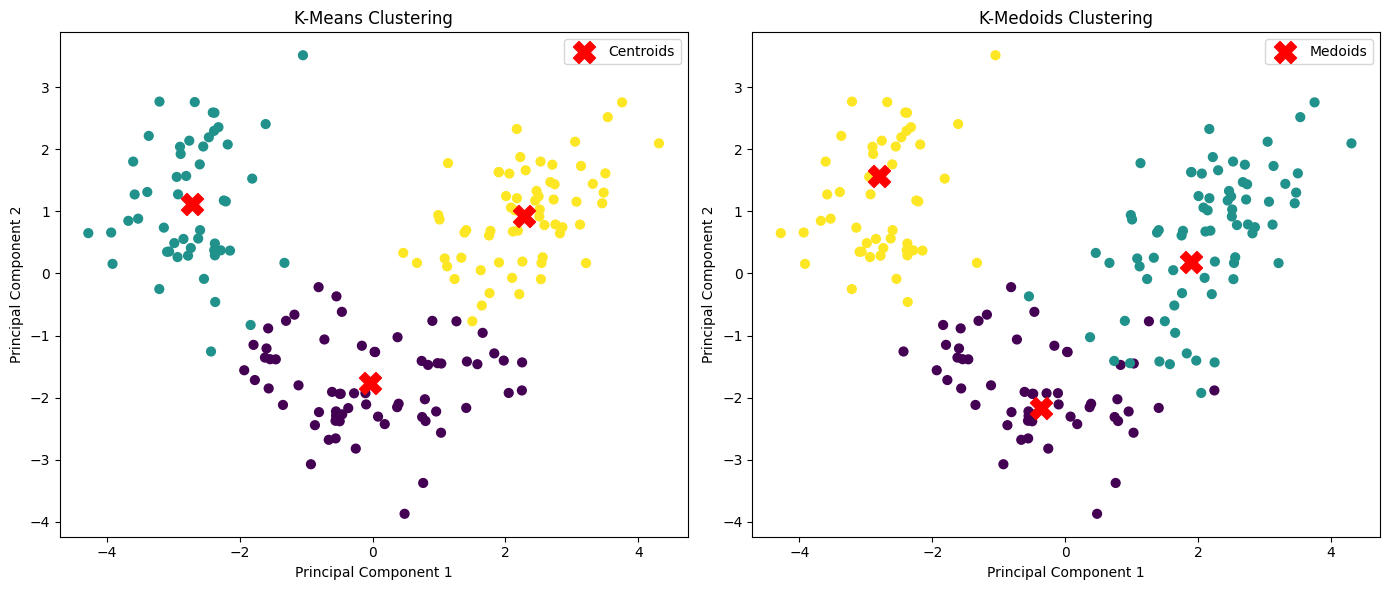

In [26]:
# Create side-by-side plots
plt.figure(figsize=(14,6))

# -------------------------
# K-Means
# -------------------------
plt.subplot(1,2,1)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap="viridis",
    s=40
)

plt.scatter(
    kmeans_centers_pca[:,0],
    kmeans_centers_pca[:,1],
    marker="X",
    s=250,
    color="red",
    label="Centroids"
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

# -------------------------
# K-Medoids
# -------------------------
plt.subplot(1,2,2)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmedoids_labels,
    cmap="viridis",
    s=40
)

plt.scatter(
    kmedoids_centers_pca[:,0],
    kmedoids_centers_pca[:,1],
    marker="X",
    s=250,
    color="red",
    label="Medoids"
)

plt.title("K-Medoids Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.tight_layout()
plt.show()

Side-by-side scatter plots are created using the first two principal components obtained from PCA. Each point represents a wine sample, colored according to its assigned cluster. The K-Means centroids and K-Medoids medoids are highlighted to show the representative center of each cluster, making it easier to compare the clustering structures produced by the two algorithms.

### Create the Performance Comparison Table

In [28]:
# Create a table comparing both clustering algorithms
comparison_df = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "K-Medoids"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        kmedoids_silhouette
    ],
    "Adjusted Rand Index (ARI)": [
        kmeans_ari,
        kmedoids_ari
    ]
})

# Round the metric values for readability
comparison_df = comparison_df.round(4)

# Display the comparison table
comparison_df

,Algorithm,Silhouette Score,Adjusted Rand Index (ARI)
0,K-Means,0.2849,0.8975
1,K-Medoids,0.2676,0.7411


The comparison table summarizes the clustering performance of K-Means and K-Medoids using the Silhouette Score and Adjusted Rand Index. These metrics provide a quantitative comparison of the two clustering algorithms.

## Clustering Analysis

### Which algorithm produced better-defined clusters?

Based on the clustering evaluation metrics, K-Means produced better-defined clusters than K-Medoids for the Wine dataset. K-Means achieved a Silhouette Score of 0.2849, which is slightly higher than the 0.2676 obtained by K-Medoids. Although both scores indicate moderate cluster separation, the higher Silhouette Score suggests that the clusters generated by K-Means are more cohesive and better separated from one another.

The difference is even more noticeable when comparing the Adjusted Rand Index (ARI). K-Means achieved an ARI of 0.8975, whereas K-Medoids obtained an ARI of 0.7411. Since the ARI measures how closely the predicted clusters match the true wine class labels, the K-Means result indicates a much stronger agreement with the actual classes. Therefore, K-Means was more successful at identifying the natural structure of the Wine dataset.


### What differences do you observe in cluster shapes or positioning?

The PCA visualization showed that both K-Means and K-Medoids separated the Wine dataset into three primary groups. However, there were noticeable differences in the placement of the cluster centers.

For K-Means, the centroids were positioned near the center of each cluster because they are calculated as the mean of all observations assigned to that cluster. This produced clusters that appeared more compact and evenly distributed, with clearer boundaries between neighboring clusters.

For K-Medoids, each cluster was represented by an actual observation from the dataset rather than an averaged center. As a result, the medoids were positioned directly on existing data points, which caused slight shifts in the cluster boundaries and positioning. Although the overall grouping remained similar to K-Means, the clusters appeared slightly less compact, and a few observations near the boundaries were assigned differently. These differences are reflected in the lower Silhouette Score and ARI values obtained by K-Medoids.

### Based on your results, explain when K-Means or K-Medoids may be preferable.

The results of this lab suggest that K-Means is the preferable algorithm for the Wine dataset because it produced higher clustering quality according to both evaluation metrics. The higher Silhouette Score indicates better cluster cohesion and separation, while the substantially higher ARI demonstrates that K-Means more accurately recovered the actual wine classes. Since the Wine dataset is relatively clean, standardized, and contains well-defined groups, K-Means was able to identify the underlying structure effectively.

However, K-Medoids remains a valuable clustering algorithm in situations where the dataset contains noise or outliers. Unlike K-Means, which computes cluster centers using the mean of all observations, K-Medoids selects actual observations as the cluster representatives. This makes K-Medoids more robust to extreme values because outliers have less influence on the location of the medoids. Although this robustness often comes at the cost of increased computational complexity and, in this case, slightly lower clustering performance, K-Medoids can be a better choice for real-world datasets that contain noisy or irregular data.

Overall, the results demonstrate that K-Means was the better-performing algorithm for the standardized Wine dataset, producing more cohesive clusters and achieving a much closer match to the true class labels. Nevertheless, both algorithms successfully identified meaningful groupings, illustrating that the choice between K-Means and K-Medoids depends on the characteristics of the dataset and whether computational efficiency or robustness to outliers is the primary objective.